# Praktikum 1 Data Mining RKA (N)

**Nama:** Muhammad Rafie Safaraz Barus

**NRP:** 5054251014

Template Kaggle Competition Praktikum Data Mining RKA.

## Setup

In [21]:
# Import Library
import os
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# tambahan library yang mungkin diperlukan
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [22]:
df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('train:', df.shape, '| test:', test.shape)

train: (8205, 33) | test: (1449, 32)


In [23]:
df.head()

,id,model_year,maker,model_family,trim,listing_city,listing_state,odometer_reading,body_color,cabin_color,...,equipment_count,has_navigation,has_backup_camera,has_bluetooth,has_heated_seats,accident_count,owner_count,commercial_use_flag,clean_title_flag,price_class
0,749,2017,Ford,Fusion,SE FWD,Charlotte,NC,18269,Ingot Silver,Ebony,...,3,0,1,1,0,0,1,0,1,1
1,5410,2016,Ford,F-150,XLT SuperCrew 5.5' Box 4WD,Reading,PA,26195,Shadow Black,Black,...,7,1,1,1,1,0,1,0,1,2
2,2758,2019,Dodge,Journey,GT AWD,Bastrop,LA,34479,Billet Clearcoat,Black/Red,...,5,0,1,1,1,0,0,0,1,2
3,7088,2017,BMW,X3,xDrive28i AWD,Harriman,NY,34083,Jet Black,Black,...,0,0,0,0,0,0,1,0,1,2
4,6319,2015,Volkswagen,e-Golf,SEL Premium,San Diego,CA,25034,Pure White,Titan Black,...,5,1,1,1,1,0,2,0,1,1


In [24]:
test.head()

,id,model_year,maker,model_family,trim,listing_city,listing_state,odometer_reading,body_color,cabin_color,...,turbo_flag,equipment_count,has_navigation,has_backup_camera,has_bluetooth,has_heated_seats,accident_count,owner_count,commercial_use_flag,clean_title_flag
0,8151,2016,Maserati,GranTurismo,Sport Coupe,Tampa,FL,24955,Bianco Eldorado,Rosso Corallo,...,NaN,0,0,0,0,0,0,1,0,1
1,5620,2007,Land,Rover Range Rover,HSE,Marietta,GA,141920,Java Black,Black,...,NaN,0,0,0,0,0,1,4,1,1
2,12,2012,Subaru,Outback,2.5i Premium Auto,Moon Township,PA,134502,Ice Silver Metallic,Off-Black,...,NaN,3,0,0,1,1,0,2,0,1
3,8027,2004,Jaguar,X-TYPE,3.0L Automatic,Glendora,CA,38638,Silver,Black,...,NaN,0,0,0,0,0,0,2,0,1
4,2450,2018,Ford,F-150,XLT SuperCrew 5.5' Box 4WD,Mesquite,TX,23931,Black Velvet,Medium Light Camel,...,NaN,3,0,1,1,0,0,1,0,1


## Exploratory Data Analysis

Lengkapi bagian ini sesuai dengan **EDA** yang kalian lakukan.

In [25]:
df.head()


,id,model_year,maker,model_family,trim,listing_city,listing_state,odometer_reading,body_color,cabin_color,...,equipment_count,has_navigation,has_backup_camera,has_bluetooth,has_heated_seats,accident_count,owner_count,commercial_use_flag,clean_title_flag,price_class
0,749,2017,Ford,Fusion,SE FWD,Charlotte,NC,18269,Ingot Silver,Ebony,...,3,0,1,1,0,0,1,0,1,1
1,5410,2016,Ford,F-150,XLT SuperCrew 5.5' Box 4WD,Reading,PA,26195,Shadow Black,Black,...,7,1,1,1,1,0,1,0,1,2
2,2758,2019,Dodge,Journey,GT AWD,Bastrop,LA,34479,Billet Clearcoat,Black/Red,...,5,0,1,1,1,0,0,0,1,2
3,7088,2017,BMW,X3,xDrive28i AWD,Harriman,NY,34083,Jet Black,Black,...,0,0,0,0,0,0,1,0,1,2
4,6319,2015,Volkswagen,e-Golf,SEL Premium,San Diego,CA,25034,Pure White,Titan Black,...,5,1,1,1,1,0,2,0,1,1


In [26]:
df.info()
df.describe()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8205 entries, 0 to 8204
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            8205 non-null   int64  
 1   model_year                    8205 non-null   int64  
 2   maker                         8205 non-null   object 
 3   model_family                  8205 non-null   object 
 4   trim                          8112 non-null   object 
 5   listing_city                  8205 non-null   object 
 6   listing_state                 8205 non-null   object 
 7   odometer_reading              8205 non-null   int64  
 8   body_color                    7980 non-null   object 
 9   cabin_color                   8000 non-null   object 
 10  city_mpg                      7681 non-null   float64
 11  highway_mpg                   7672 non-null   float64
 12  engine_spec                   8125 non-null   object 
 13  gea

np.int64(0)

In [27]:
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()

print(df[kolom_numerik].describe().round(2).T)
print()

                               count      mean       std      min       25%  \
id                            8205.0   4838.60   2781.07     1.00   2435.00   
model_year                    8205.0   2014.18      4.60  1997.00   2012.00   
odometer_reading              8205.0  74516.32  52137.44     6.00  35335.00   
city_mpg                      7681.0     22.96     12.96     8.00     17.00   
highway_mpg                   7672.0     30.17     10.67    12.00     24.00   
model_year_gap_2020           8205.0      5.82      4.60     0.00      3.00   
odometer_per_model_year_2021  8205.0  11831.79   6345.17     2.43   7576.25   
combined_mpg                  7547.0     26.58     11.72    10.00     20.50   
mpg_spread                    7547.0      7.23      4.06   -29.00      6.00   
engine_displacement_l         8030.0      3.02      1.32     0.60      2.00   
cylinder_count                8015.0      5.32      1.60     2.00      4.00   
turbo_flag                    8125.0      0.27      

In [28]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.to_frame("jumlah_missing").assign(
    persentase=lambda x: (x["jumlah_missing"] / len(df) * 100).round(2)
))

,jumlah_missing,persentase
mpg_spread,658,8.02
combined_mpg,658,8.02
highway_mpg,533,6.50
city_mpg,524,6.39
body_color,225,2.74
cabin_color,205,2.50
cylinder_count,190,2.32
engine_displacement_l,175,2.13
trim,93,1.13
turbo_flag,80,0.98


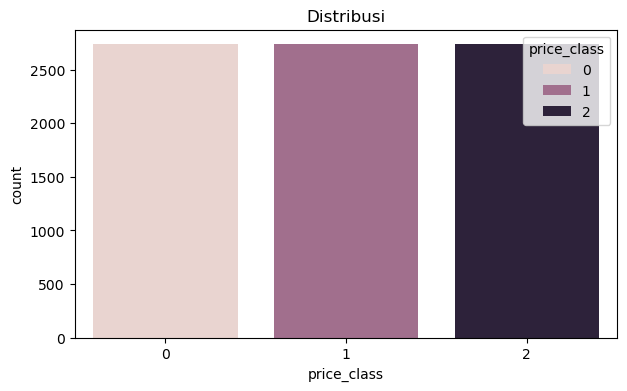

In [29]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="price_class", hue="price_class")
plt.title("Distribusi")

plt.show()

In [30]:
numeric_cols = df.select_dtypes(include=np.number).columns
correlation = df[numeric_cols].corr()["price_class"].drop("price_class").abs()
display(correlation.sort_values(ascending=False).to_frame("absolute_correlation"))

,absolute_correlation
odometer_reading,0.599322
model_year,0.583182
model_year_gap_2020,0.583182
owner_count,0.438265
has_backup_camera,0.262778
turbo_flag,0.247098
equipment_count,0.236723
accident_count,0.188521
highway_mpg,0.151245
commercial_use_flag,0.150767


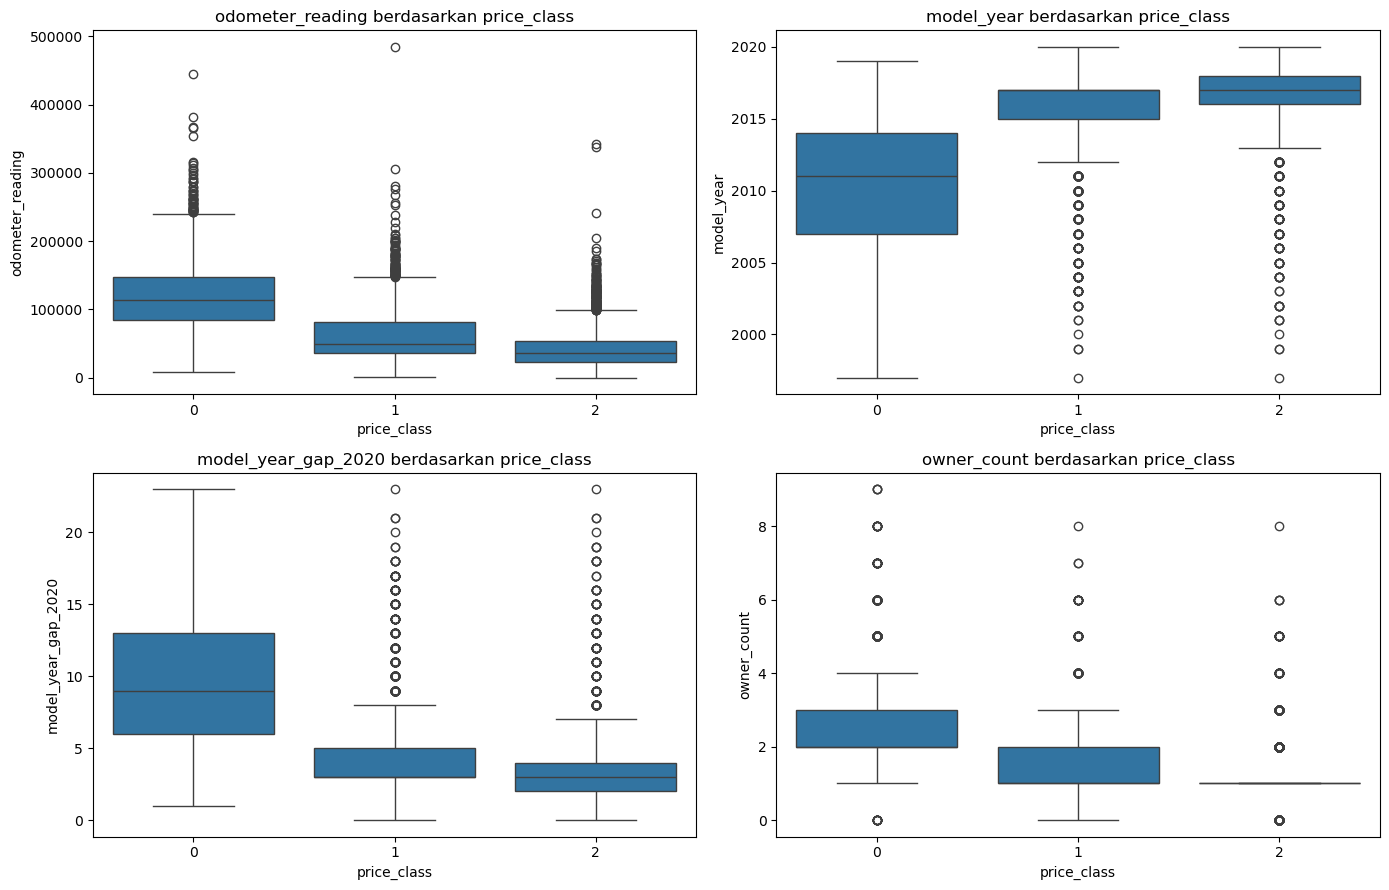

In [31]:
top_features = correlation.sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, top_features):
    sns.boxplot(data=df, x="price_class", y=col, ax=ax)
    ax.set_title(f"{col} berdasarkan price_class")
plt.tight_layout()
plt.show()

In [32]:
print("Jumlah baris duplikat:", df.duplicated().sum())
print("Jumlah ID unik:", df["id"].nunique(), "dari", len(df))


object_cols = df.select_dtypes(include="object").columns
cardinality = df[object_cols].nunique().sort_values(ascending=False)
print("\nKolom teks dengan jumlah kategori terbanyak:")
display(cardinality.to_frame("jumlah_kategori"))


Jumlah baris duplikat: 0
Jumlah ID unik: 8205 dari 8205

Kolom teks dengan jumlah kategori terbanyak:


,jumlah_kategori
trim,1707
listing_city,1551
body_color,959
cabin_color,528
model_family,474
engine_spec,173
listing_state,50
maker,49
energy_source,7
drive_layout,4


In [33]:
outlier_summary = []
for col in numeric_cols.drop("price_class"):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    jumlah = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
    outlier_summary.append([col, jumlah])

outlier_summary = pd.DataFrame(outlier_summary, columns=["kolom", "jumlah_outlier"])
display(outlier_summary.sort_values("jumlah_outlier", ascending=False))


,kolom,jumlah_outlier
16,has_heated_seats,1965
19,commercial_use_flag,1819
17,accident_count,1586
13,has_navigation,1077
18,owner_count,617
1,model_year,416
5,model_year_gap_2020,416
8,mpg_spread,253
6,odometer_per_model_year_2021,248
3,city_mpg,246


In [ ]:
# ringkasan target berdasarkan fitur kategorikal utama
for col in ["maker", "energy_source", "drive_layout", "gearbox"]:
    print(f"\nRata-rata price_class berdasarkan {col}:")
    display(df.groupby(col)["price_class"].agg(["count", "mean"]).sort_values("mean", ascending=False).head(10))
    


Rata-rata price_class berdasarkan maker:


,count,mean
maker,,
Aston,8,2.000000
Ferrari,8,2.000000
Bentley,12,2.000000
Karma,1,2.000000
Lamborghini,2,2.000000
Rolls-Royce,2,2.000000
Maybach,2,2.000000
Maserati,16,1.875000
Ram,225,1.755556



Rata-rata price_class berdasarkan energy_source:


,count,mean
energy_source,,
Hydrogen,8,1.250000
Plug-In,111,1.144144
Gas,7643,1.009420
Diesel,161,0.962733
Hybrid,189,0.804233
CNG,5,0.800000
Electric,88,0.454545



Rata-rata price_class berdasarkan drive_layout:


,count,mean
drive_layout,,
4WD,1665,1.437237
AWD,1050,1.229524
RWD,1164,0.993127
FWD,4326,0.777393



Rata-rata price_class berdasarkan gearbox:


,count,mean
gearbox,,
Automatic,7962,1.013816
Manual,243,0.539095


## Preprocessing

Lengkapi bagian ini sesuai dengan **Preprocessing Data** yang kalian lakukan

<Axes: title={'center': 'Persentase Nilai Kosong per Kolom'}>

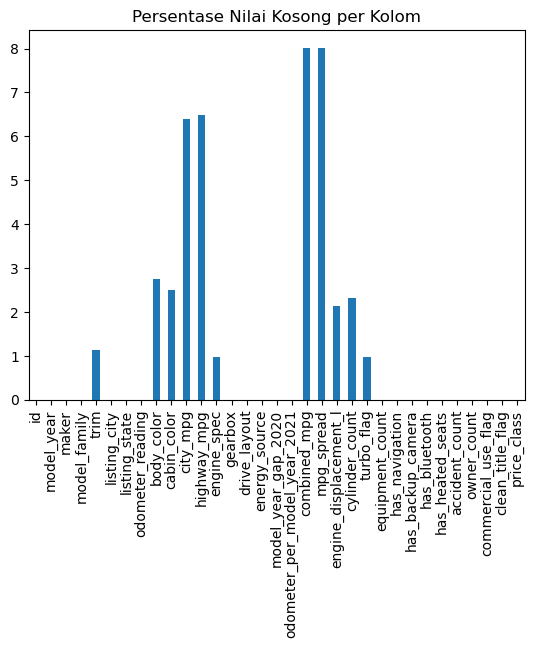

In [ ]:
# grafik persentase nilai kosong per kolom
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_percent.plot(kind="bar", title="Persentase Nilai Kosong per Kolom")
    

Menangani Nilai Hilang Lainnya


In [ ]:
# menangani nilai hilang pada data train dan test
df_processed = df.copy()
test_processed = test.copy()

kolom_kategorikal = df_processed.select_dtypes(include="object").columns
kolom_numerik = df_processed.select_dtypes(exclude="object").columns.drop("price_class")


In [ ]:
# nilai kategorikal diisi dengan modus data train
for col in kolom_kategorikal:
    modus = df_processed[col].mode()[0]
    df_processed[col] = df_processed[col].fillna(modus)
    test_processed[col] = test_processed[col].fillna(modus)

In [ ]:
# nilai numerik diisi dengan median data train
for col in kolom_numerik:
    median = df_processed[col].median()
    df_processed[col] = df_processed[col].fillna(median)
    test_processed[col] = test_processed[col].fillna(median)

In [ ]:
# encoding fitur kategorikal
X = pd.get_dummies(df_processed.drop(columns="price_class"), dtype=int)
X_test = pd.get_dummies(test_processed, dtype=int)

In [57]:
# nyamain kolom train dan test
X_test = X_test.reindex(columns=X.columns, fill_value=0)

y = df_processed["price_class"]

print("Missing values pada X:", X.isnull().sum().sum())
print("Missing values pada X_test:", X_test.isnull().sum().sum())
print("Ukuran X:", X.shape, "| Ukuran X_test:", X_test.shape)

Missing values pada X: 0
Missing values pada X_test: 0
Ukuran X: (8205, 5525) | Ukuran X_test: (1449, 5525)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("y_train:", y_train.shape, "| y_val:", y_val.shape)

X_train: (6564, 5525) | X_val: (1641, 5525)
y_train: (6564,) | y_val: (1641,)


In [52]:
df_test = test_processed.copy()

print("df_test:", df_test.shape)
print("X_test:", X_test.shape)

df_test: (1449, 32)
X_test: (1449, 5525)


## Modeling 

**DILARANG MENGUBAH CODE!!!!!!!!!!!!**, sesuaikan semua varible yang dibutuhkan.

**Pastikan sudah memiliki variable berikut:**
`X_train, X_val, y_train, y_val -> df_train`

In [56]:
# Modeling using Decision Tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"Precision: {precision_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"Recall: {recall_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"F1: {f1_score(y_val, y_pred, average='macro', zero_division=0)}")
print(classification_report(y_val, y_pred, zero_division=0))

Accuracy: 0.8080438756855576
Precision: 0.8082158121215004
Recall: 0.8080438756855576
F1: 0.8081280792952953
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       547
           1       0.72      0.72      0.72       547
           2       0.86      0.86      0.86       547

    accuracy                           0.81      1641
   macro avg       0.81      0.81      0.81      1641
weighted avg       0.81      0.81      0.81      1641



# Submission

**DILARANG MENGUBAH CODE!!!!!!!!!!!**

**Pastikan memiliki variable berikut:**
`X_test -> df_test`

In [54]:
id = df_test['id'].tolist()

y_test = model.predict(X_test)
submission_df = pd.DataFrame({'id': id, 'price': y_test})
submission_df.to_csv('submission.csv', index=False)